# GBM drift and volatility with Nested Sampling

One-year estimation windows, weekly log-returns, nested sampling posterior for annualized `mu` and `sigma`, plus a restricted `mu = 0` model for evidence comparison.

In [19]:
import dynesty
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from dynesty import plotting as dyplot
from dynesty.utils import quantile

In [20]:
stock_name = 'AAPL'
start_year = 2000
end_year = 2023

return_window = 5
dt = return_window / 252

mu_min, mu_max = -2.0, 2.0
sigma_min, sigma_max = 0.01, 3.0

nlive = 300
dlogz = 0.05
random_seed = 123
example_year = 2023

In [21]:
downloaded = yf.download(
    stock_name,
    start=f'{start_year}-01-01',
    end=f'{end_year + 1}-01-01',
    auto_adjust=False,
    progress=False,
)

prices = downloaded['Close']
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()
prices.head()

Date
2000-01-03    0.999442
2000-01-04    0.915179
2000-01-05    0.928571
2000-01-06    0.848214
2000-01-07    0.888393
Name: AAPL, dtype: float64

In [22]:
def get_year_returns(prices, year, return_window):
    year_prices = prices.loc[prices.index.year == year].dropna()
    weekly_prices = year_prices.iloc[::return_window]
    log_returns = np.log(weekly_prices / weekly_prices.shift(1)).dropna().to_numpy()
    return year_prices, log_returns


def prior_transform_full(u):
    x = np.array(u)
    x[0] = mu_min + x[0] * (mu_max - mu_min)
    x[1] = sigma_min + x[1] * (sigma_max - sigma_min)
    return x


def prior_transform_mu0(u):
    x = np.array(u)
    x[0] = sigma_min + x[0] * (sigma_max - sigma_min)
    return x


def make_loglike_full(log_returns):
    def loglike(theta):
        mu, sigma = theta
        mean = (mu - 0.5 * sigma**2) * dt
        std = sigma * np.sqrt(dt)
        residual = (log_returns - mean) / std
        return -0.5 * np.sum(residual**2 + np.log(2 * np.pi * std**2))

    return loglike


def make_loglike_mu0(log_returns):
    def loglike(theta):
        sigma = theta[0]
        mean = -0.5 * sigma**2 * dt
        std = sigma * np.sqrt(dt)
        residual = (log_returns - mean) / std
        return -0.5 * np.sum(residual**2 + np.log(2 * np.pi * std**2))

    return loglike

In [23]:
def posterior_summary_full(results):
    samples = results.samples
    weights = results.importance_weights()
    row = {}

    for name, values in [('mu', samples[:, 0]), ('sigma', samples[:, 1])]:
        low, median, high = quantile(values, [0.025, 0.5, 0.975], weights=weights)
        mean = np.average(values, weights=weights)
        std = np.sqrt(np.average((values - mean)**2, weights=weights))
        row[f'{name}_mean'] = mean
        row[f'{name}_std'] = std
        row[f'{name}_q025'] = low
        row[f'{name}_median'] = median
        row[f'{name}_q975'] = high

    return row


def posterior_summary_mu0(results):
    sigma = results.samples[:, 0]
    weights = results.importance_weights()
    low, median, high = quantile(sigma, [0.025, 0.5, 0.975], weights=weights)
    mean = np.average(sigma, weights=weights)
    std = np.sqrt(np.average((sigma - mean)**2, weights=weights))

    return {
        'mu0_sigma_mean': mean,
        'mu0_sigma_std': std,
        'mu0_sigma_q025': low,
        'mu0_sigma_median': median,
        'mu0_sigma_q975': high,
    }

In [24]:
def run_nested_for_year(year):
    year_prices, log_returns = get_year_returns(prices, year, return_window)

    sampler_full = dynesty.NestedSampler(
        make_loglike_full(log_returns),
        prior_transform_full,
        ndim=2,
        nlive=nlive,
        rstate=np.random.default_rng(random_seed + year),
    )
    sampler_full.run_nested(dlogz=dlogz, print_progress=False)

    sampler_mu0 = dynesty.NestedSampler(
        make_loglike_mu0(log_returns),
        prior_transform_mu0,
        ndim=1,
        nlive=nlive,
        rstate=np.random.default_rng(random_seed + 10000 + year),
    )
    sampler_mu0.run_nested(dlogz=dlogz, print_progress=False)

    results_full = sampler_full.results
    results_mu0 = sampler_mu0.results

    row = posterior_summary_full(results_full)
    row.update(posterior_summary_mu0(results_mu0))
    row['year'] = year
    row['price_observations'] = len(year_prices)
    row['return_observations'] = len(log_returns)
    row['logz_full'] = results_full.logz[-1]
    row['logzerr_full'] = results_full.logzerr[-1]
    row['logz_mu0'] = results_mu0.logz[-1]
    row['logzerr_mu0'] = results_mu0.logzerr[-1]
    row['log_bayes_factor_full_vs_mu0'] = row['logz_full'] - row['logz_mu0']

    return row, results_full, results_mu0

In [29]:
rows = []
yearly_results_full = {}
yearly_results_mu0 = {}

for year in range(start_year, end_year + 1):
    print(f'Running {year}')
    row, results_full, results_mu0 = run_nested_for_year(year)
    rows.append(row)
    yearly_results_full[year] = results_full
    yearly_results_mu0[year] = results_mu0

yearly_summary = pd.DataFrame(rows).sort_values('year').reset_index(drop=True)

Running 2000
Running 2001
Running 2002
Running 2003
Running 2004
Running 2005
Running 2006
Running 2007
Running 2008
Running 2009
Running 2010
Running 2011
Running 2012
Running 2013
Running 2014
Running 2015
Running 2016
Running 2017
Running 2018
Running 2019
Running 2020
Running 2021
Running 2022
Running 2023


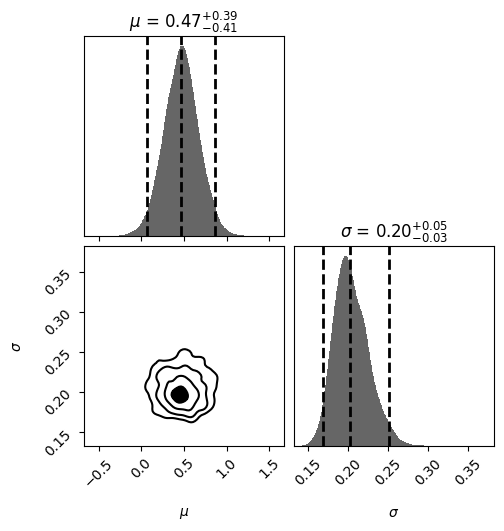

In [27]:
results_full = yearly_results_full[example_year]
results_mu0 = yearly_results_mu0[example_year]

fg, axs = dyplot.cornerplot(
    results_full,
    labels=[r'$\mu$', r'$\sigma$'],
    show_titles=True,
)

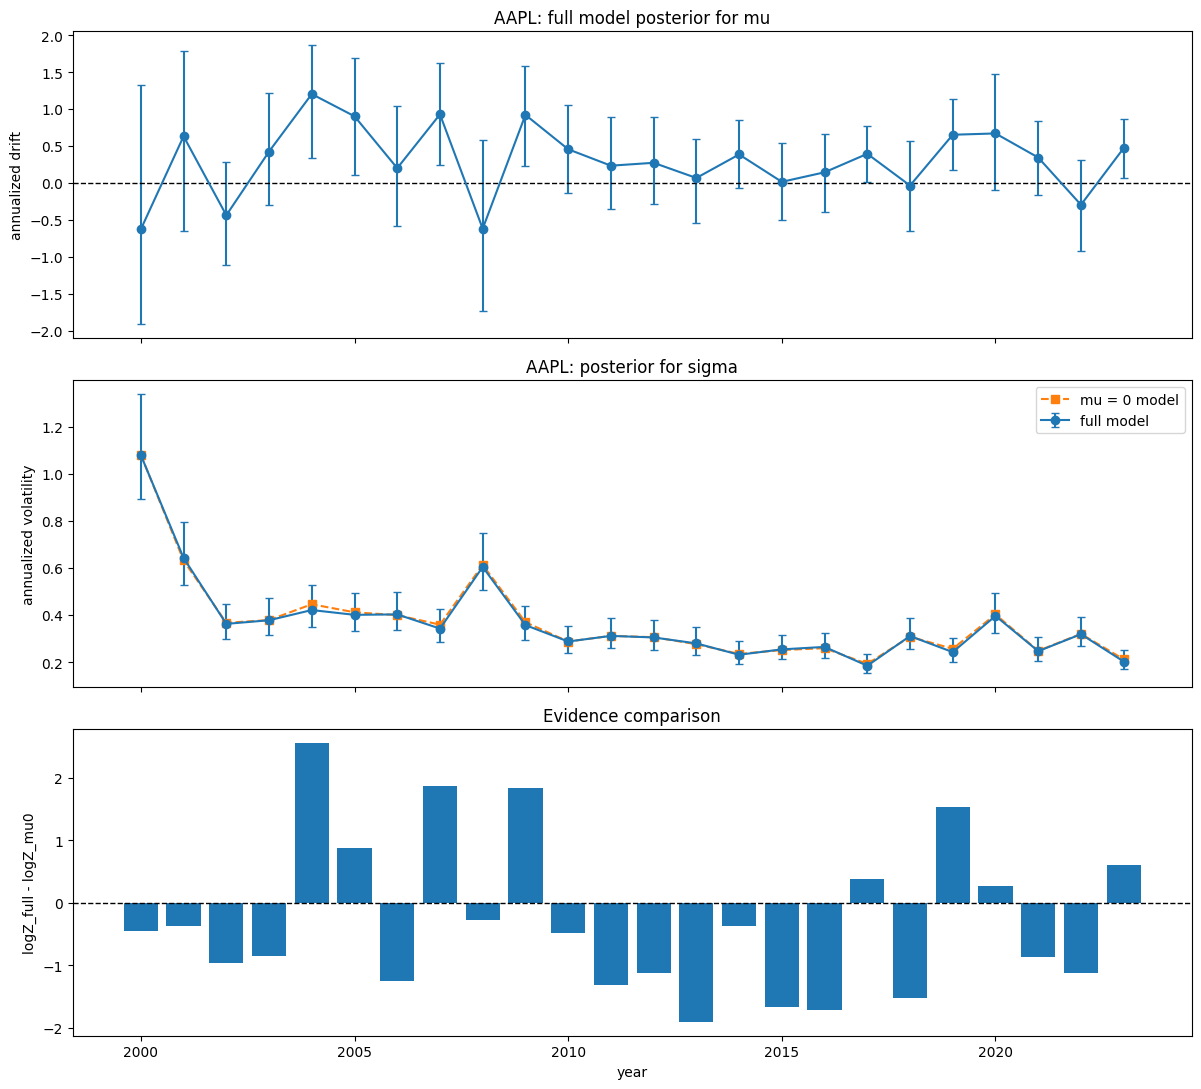

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

mu_yerr = [
    yearly_summary['mu_median'] - yearly_summary['mu_q025'],
    yearly_summary['mu_q975'] - yearly_summary['mu_median'],
]
axes[0].errorbar(yearly_summary['year'], yearly_summary['mu_median'], yerr=mu_yerr, fmt='o-', capsize=3)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('annualized drift')
axes[0].set_title(f'{stock_name}: full model posterior for mu')

sigma_yerr = [
    yearly_summary['sigma_median'] - yearly_summary['sigma_q025'],
    yearly_summary['sigma_q975'] - yearly_summary['sigma_median'],
]
axes[1].errorbar(yearly_summary['year'], yearly_summary['sigma_median'], yerr=sigma_yerr, fmt='o-', capsize=3, label='full model')
axes[1].plot(yearly_summary['year'], yearly_summary['mu0_sigma_median'], 's--', label='mu = 0 model')
axes[1].set_ylabel('annualized volatility')
axes[1].set_title(f'{stock_name}: posterior for sigma')
axes[1].legend()

axes[2].bar(yearly_summary['year'], yearly_summary['log_bayes_factor_full_vs_mu0'])
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('year')
axes[2].set_ylabel('logZ_full - logZ_mu0')
axes[2].set_title('Evidence comparison')

fig.tight_layout()